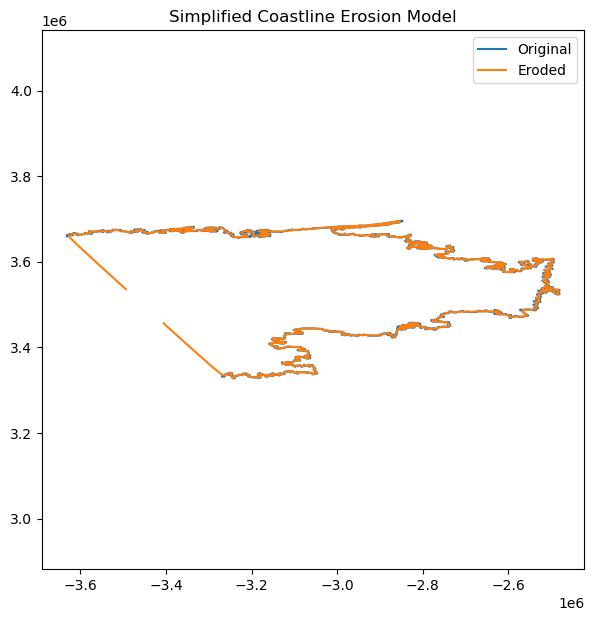

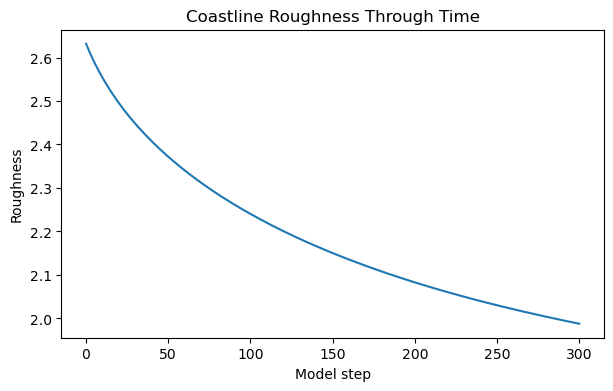

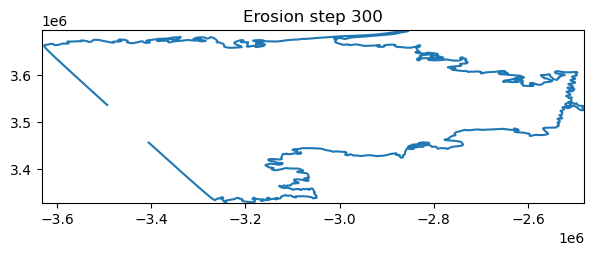

In [2]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from matplotlib.animation import FuncAnimation

# -----------------------
# 1. Load coastline GeoJSON
# -----------------------
file = "C:/Users/isabe/Downloads/clippedcoast.json"   # change this
gdf = gpd.read_file(file)
gdf.to_file("last_try", driver="GeoJSON")

# If CRS is geographic lat/lon, project it so distances are in meters
# For Titan/unknown coordinates, skip this unless you have a real projection
# gdf = gdf.to_crs("EPSG:3857")

# -----------------------
# 2. Extract longest coastline
# -----------------------
lines = []

for geom in gdf.geometry:
    if geom.geom_type == "LineString":
        lines.append(geom)
    elif geom.geom_type == "MultiLineString":
        lines.extend(list(geom.geoms))
    elif geom.geom_type == "Polygon":
        lines.append(geom.exterior)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            lines.append(poly.exterior)

coastline = max(lines, key=lambda g: g.length)

coords = np.array(coastline.coords)
x = coords[:, 0].astype(float)
y = coords[:, 1].astype(float)

# If the coastline is closed, remove duplicate final point
if np.allclose([x[0], y[0]], [x[-1], y[-1]]):
    x = x[:-1]
    y = y[:-1]

# -----------------------
# 3. Erosion model settings
# -----------------------
steps = 300
dt = 0.1
k = 0.05          # erosion strength; increase for faster smoothing
wave_amp = 0.6    # unevenness of wave energy around coast

n = len(x)

# Simple wave-energy pattern around the coastline
wave_energy = 1 + wave_amp * np.sin(np.linspace(0, 4 * np.pi, n))

# -----------------------
# 4. Helper functions
# -----------------------
def roughness(x, y):
    """
    Simple roughness metric:
    coastline length / straight-line or perimeter-scale distance.
    For closed coastlines, compares actual length to convex hull perimeter.
    """
    line = LineString(np.column_stack([x, y]))
    hull_perim = line.convex_hull.length
    return line.length / hull_perim

def erosion_step(x, y):
    """
    Smooths the coastline using a Laplacian-style update.
    This is a simplified wave-erosion proxy:
    high-curvature sections smooth/retreat more, scaled by wave energy.
    """
    x_lap = np.roll(x, -1) - 2*x + np.roll(x, 1)
    y_lap = np.roll(y, -1) - 2*y + np.roll(y, 1)

    x_new = x + k * wave_energy * x_lap * dt
    y_new = y + k * wave_energy * y_lap * dt

    return x_new, y_new

# -----------------------
# 5. Run model
# -----------------------
x_hist = [x.copy()]
y_hist = [y.copy()]
roughness_hist = [roughness(x, y)]

for step in range(steps):
    x, y = erosion_step(x, y)
    x_hist.append(x.copy())
    y_hist.append(y.copy())
    roughness_hist.append(roughness(x, y))

# -----------------------
# 6. Plot before/after
# -----------------------
plt.figure(figsize=(7, 7))
plt.plot(x_hist[0], y_hist[0], label="Original")
plt.plot(x_hist[-1], y_hist[-1], label="Eroded")
plt.axis("equal")
plt.legend()
plt.title("Simplified Coastline Erosion Model")
plt.show()

# -----------------------
# 7. Plot roughness over time
# -----------------------
plt.figure(figsize=(7, 4))
plt.plot(roughness_hist)
plt.xlabel("Model step")
plt.ylabel("Roughness")
plt.title("Coastline Roughness Through Time")
plt.show()

# -----------------------
# 8. Save eroded coastline as GeoJSON
# -----------------------
eroded_line = LineString(np.column_stack([x_hist[-1], y_hist[-1]]))

out = gpd.GeoDataFrame(
    {"name": ["eroded_coastline"]},
    geometry=[eroded_line],
    crs=gdf.crs
)

out.to_file("eroded_coastline.geojson", driver="GeoJSON")

# -----------------------
# 9. Make animation
# -----------------------
fig, ax = plt.subplots(figsize=(7, 7))
line, = ax.plot(x_hist[0], y_hist[0])

ax.set_aspect("equal")
ax.set_xlim(np.min(x_hist[0]), np.max(x_hist[0]))
ax.set_ylim(np.min(y_hist[0]), np.max(y_hist[0]))

def update(frame):
    line.set_data(x_hist[frame], y_hist[frame])
    ax.set_title(f"Erosion step {frame}")
    return line,

ani = FuncAnimation(fig, update, frames=len(x_hist), interval=40)
ani.save("coastline_erosion.gif", writer="pillow", fps=20)
plt.show()